# Using lkdata

lkdata is a python package designed to handle time-series data transformations using the built-in power of [pandas](https://pandas.pydata.org/). lkdata serves at the backend for lightkurve v3. lightkurve users will typically not interact with lkdata directly. However, they are used for the affiliated packages to process [Lightcurve](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=32) (LC), [Target Pixel File](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=24) (TPF), and [Full Frame Image](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=18) (FFI) [data](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) for the [TESS](https://tess.mit.edu) and [Kepler/K2](https://science.nasa.gov/mission/kepler/) missions. 

The previous notebook covered the basics of the different types of data structures available in lkdata. 
In this notbook, we will apply those principles to TESS data. This notebook oulines the basic framework used by lightkurve version 3. 


In [1]:
# Import all of the packages we will use throughout this notebook
import sys
import os
parent_dir_name = os.path.dirname(os.path.dirname(os.path.dirname(os.path.realpath('lkdata'))))
sys.path.append(parent_dir_name + "/src")
import lkdata
import lksearch
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
print(lkdata.__path__)

['/Users/nthom/TESS_GI/gitNschanch/tessgi/lkdata/src/lkdata']


# 1 - Introduction to TESS

The Transiting Exoplanet Survey Satellite (TESS) was launched in April 2018. The initial goal for TESS was to identify exoplanets transiting orbiting bright host stars. However, as an all-sky survey with precise, high cadence observations, TESS has opened up a wide range of science including, but certainly not limited to, stellar flares, asteroseismology, asteroid detection, and supernovae science. 

TESS has 3 main data types. 
   1) Full Frame Images: Large images covering the full CCD frame, with a cadence of 30-min (years 1 & 2), 10-min (years 3 & 4), or 200-sec (years 5+).
   2) Target Pixel Files: Postage stamp cut outs from the FFIs, focused on a selected target of interest. Each stamp has a cadence of 2-min or (starting in year 3) 20-sec.
   3) Light Curve Files: The time series data produced for each 2-min or 20-sec TPF object.

given that all of these data products are timeseires, they can be described by lkdata using a set of DataSeries and DataCube products. By reading in the data in this format, we can manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations quickly and simply. This notebook will introduce users to the basics. For further information, we direct users to the lightkurve v3 documentation (in development). 

# 2 - Example TESS data

Before we get any further, let's get some data we can use to motivate the different functionality. K2-18 b is a Hycean planet originally found by the K2 mission. Subsequently, this planet has been observed by TESS. Let's download a TPF cutout from the FFI using TESScut using [lksearch](https://github.com/lightkurve/lksearch).

In [42]:
# Search for data we will use to populate our DataCube
results = lksearch.TESSSearch('K2-18', exptime=600).cubedata
results

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,388804061,TESS-SPOC,HLSP,45,600.0,0.0,2021,FITS
1,388804061,TESS-SPOC,HLSP,46,600.0,0.0,2021,FITS
2,"172.56049060233, 7.58840426347",TESScut,TESS Sector 45,45,600.0,0.0,2021,TESS FFI Cutout (sector 45)
3,"172.56049060233, 7.58840426347",TESScut,TESS Sector 46,46,600.0,0.0,2021,TESS FFI Cutout (sector 46)
4,"172.56049060233, 7.58840426347",TESScut,TESS Sector 72,72,200.0,0.0,2023,TESS FFI Cutout (sector 72)


Now that we have a list of available data products, lets download one of them. Specifically let's use [TESScut](https://mast.stsci.edu/tesscut/docs/index.html) to extract a TPF from sector 45.  Further, let's use an uneven size to make the later transformations more clear.

In [45]:
manifest = results[2].download(TESScut_size=(11,9))
manifest

,Local Path,Status
0,/Users/nthom/.lksearch/cache/mastDownload/TESS...,COMPLETE


In [47]:
# Read in our downloaded file using astropy's fits functionality
tpf = fits.open(manifest['Local Path'][0])
tpf

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x17aa023d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x17babc700>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11faca130>]

A DataCube product requires a minimum of two components: a 1-d array containing the time and a 3D array with shape (ntime, nrow, ncol).

We will start by making a simple DataCube object that just contains the time, flux, and flux error information. Note that additional time series information, such as the time correction applied to the data, could also be stored in the Cube.  

In [48]:
time = tpf[1].data['TIME']
timecorr = tpf[1].data['TIMECORR'] #light arrival time correction applied
flux = tpf[1].data['FLUX']#.transpose([0,2,1]) # a TPF has a shape (ntimes, ncol, nrow), so we need to transpose this for our DataCube
flux_err = tpf[1].data['FLUX_ERR']#.transpose([0,2,1])
time.shape, flux.shape, flux_err.shape

((3450,), (3450, 11, 9), (3450, 11, 9))

In this example, in addition to the time values, we will add an additional non-standard time index. Namely, we will add the 'timecorr' value provided in the TPF file. This is an array that contains the light arrival time correction applied by the pipeline at each time step. 

Note that the timecorr array has an additional byteswap().newbyteorder() appended to the end. Occasionally you may have to deal with data that were created on a machine with a different byte order than the one on which you are running Python. Without these lines, you will receive the following error, "ValueError: Big-endian buffer not supported on little-endian compiler". 

In [49]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
)

                                   

The DataCube now is storing the flux and error as a pandas dataframe. This allows us to use the built-in feature of pandas, as well as add some useful new properties. 

Let's take a look at the data in more detail. The DataCube is visually represented as a 2-dimensional grid that by default shows the first image in the time series. The data (in this case the raw flux) is shown in the grid, with a grayscale colorbar the allows you to visualize what the image looks like. 

In [50]:
cube

📘 DataCube (3450, 11, 9), Uncertainty: True

That looks like a cube, but perhaps we want to retain the pixel location on the CCD. We can do that by defining the row and column based on the TESS header data. To learn more about what information is stored in the TESS header, you can check out [the data product description document](https://ntrs.nasa.gov/api/citations/20180007935/downloads/20180007935.pdf). 

In [51]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       # Note TESS time by default is the Barycentric Julian Data with an offset of 2457000
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()}, 
                       row_indices={'pixel_row':np.arange(lcf[1].header['2CRV4P'], lcf[1].header['2CRV4P'] + flux.shape[1])},
                       col_indices={'pixel_col':np.arange(lcf[1].header['1CRV4P'], lcf[1].header['1CRV4P'] + flux.shape[2])}
)


cube

📘 DataCube (3450, 11, 9), Uncertainty: True

We can get more information about our newly created DataCube by using the .describe_cube() function. You can see that our DataCube contains 3,450 time steps for the data as well as the uncertainty. There are 3 time indices available including the time in BJD and the time correction used by the pipeline. 

In [52]:
cube.describe_cube()

📘 DataCube (3450, 11, 9), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (3450, 99)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(3450, 11, 9))

Time indices available: ['time_index', 'time', 'timecorr']
	time_index  :	[   0    1 ... 3448 3449]
	time        :	[2459525.50722746 2459525.51417241 ... 2459550.61369164 2459550.62063674]
	timecorr    :	[-0.00325851 -0.003258   ... -0.00094983 -0.00094917]

Number of unique 'series': 99

Row names: ['pixel_row']
	pixel_row   :	[1002 1002 ... 1012 1012]

Column names: ['pixel_col']
	pixel_col   :	[583 584 ... 590 591]

User defined attributes accessible via `object.key`
(displaying only unique values)


## 2.1 - Slicing 

Now that we have a DataCube, we can start to manipulate our data. The nice thing about the DataCube is that it applies your slice to the time, data, and data errors automatically. 

**Note that the rows/columns are trasformed when being stored as a pandas dataframe. However, when you slice, you can slice using [time, row, col]**

You can plot the DataCube in a 'lightkurve-like' way using matplotlib.imshow(). This example in the cell below plots the first time step. Note we have to set the extent to display the row and column information

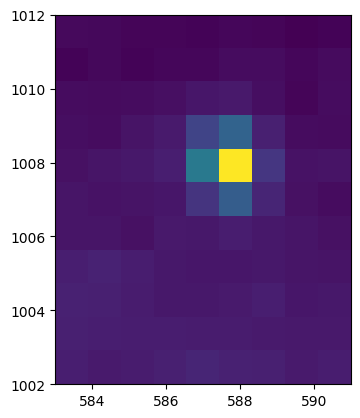

In [53]:

plt.imshow(cube[0,:,:].data[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 


/Users/nthom/opt/anaconda3/envs/py3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/nthom/.lightkurve/cache. Please move all the files in the legacy directory /Users/nthom/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

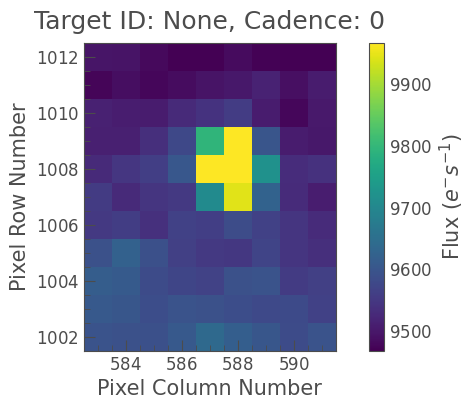

In [54]:
# TODO: I'll probably remove this, but it's a nice sanity check. What do you think?
import lightkurve as lk
tpf = lk.read(manifest['Local Path'][0])
tpf.plot()

Now that we can plot the data, let's take a closer look at the target star. First, we can identify the pixel location with the brightest flux. We can then use the pixel location to define a simple aperture, which for example could be used to extract a lightcurve.

In [56]:

brightest_time, brightest_row, brightest_col = np.where(cube.data == np.max(cube.data))
#brightest_time = brightest_times, brightest_row, brightest_col 
print(brightest_time, brightest_row, brightest_col)



[106] [6] [5]


In [82]:
# Get all time steps for the pixels containing the target star
target = cube[:, brightest_row[0]-1:brightest_row[0]+2, brightest_col[0]-1:brightest_col[0]+2] # Remember, this is [time, row, column]
target

📘 DataCube (3450, 3, 3), Uncertainty: True

In [84]:
targetlc = target.sum(axis=1)
targetlc

time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06    83249.914062
1           2.459526e+06  -0.003258  2.459526e+06    84918.554688
2           2.459526e+06  -0.003257  2.459526e+06    86508.109375
3           2.459526e+06  -0.003257  2.459526e+06    87895.781250
4           2.459526e+06  -0.003256  2.459526e+06    88937.570312
                                                         ...     
3445        2.459551e+06  -0.000952  2.459551e+06     6235.246094
3446        2.459551e+06  -0.000951  2.459551e+06     6228.056152
3447        2.459551e+06  -0.000950  2.459551e+06     6228.932129
3448        2.459551e+06  -0.000950  2.459551e+06     6231.092285
3449        2.459551e+06  -0.000949  2.459551e+06     6227.060059
Length: 3450, dtype: float32


📉 DataSeries (3450,)

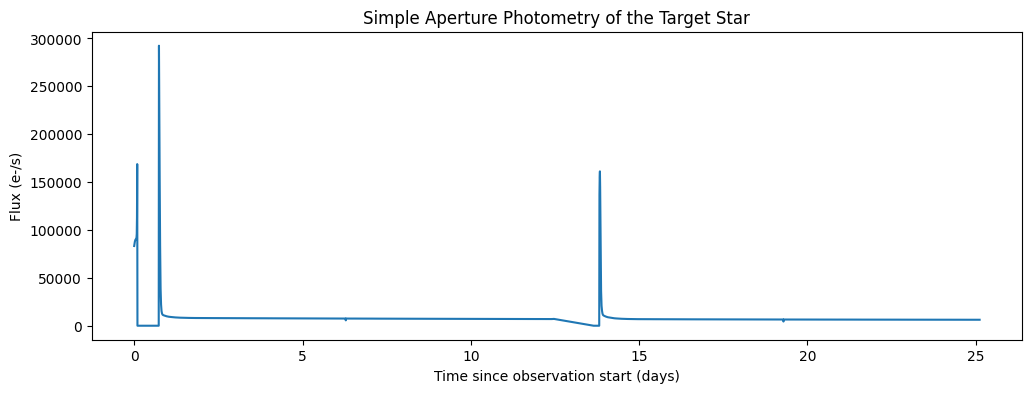

In [90]:
fig, ax = plt.subplots(1, figsize=(12,4))
ax.plot(targetlc.time - min(targetlc.time), targetlc.data)
ax.set_title("Simple Aperture Photometry of the Target Star")
ax.set_xlabel('Time since observation start (days)')
ax.set_ylabel('Flux (e-/s)')
plt.show()

Now we have made our own Simple Aperture Photometry lightcurve for the target star. You can see there are some large spikes in the data at the start and at the midpoint. These are due to scattered light at the beginning of each orbit. We leave it as an exercise to remove the scattered light trend by using the background pixels (see this [lightkurve tutorial](https://lightkurve.github.io/lightkurve/tutorials/2-creating-light-curves/2-1-cutting-out-tpfs.html) for more information). 

## 2.2 Binning

Often you may want to bin the data. For example, you may want to bin in the time dimension to reduce the noise to bring out features in the data or bin in the spatial dimension to visualize what your data at a lower resolution. The DataCube object makes this easy. In the example below, we first bine by time, then bin pixels togehter in one line of code. 

In [58]:
# TODO: note this is not a length of 690 (3450/5), so this must mean 3 bins were not 'full' 
cube.downsample(nframes=5, level="time").spatial_downsample(factor=2)

📘 DataCube (687, 5, 4), Uncertainty: True

## 2.3 - Other Properties

DataCube objects have other properties you can access directly. These include col, row, and uncertainty. Note col and row are the same for all images in the stack. However, the uncertainties match the dimensions of the data. 

In [59]:
cube.pixel_col.shape, cube.pixel_row.shape, cube.uncertainty.shape


((99,), (99,), (3450, 11, 9))

You can also perform math operations on the DataCube. For example, we could create a 2D image containing the median data for each pixel. Note this returns the median data as well as the associated uncertainties

In [60]:
cube.mean(axis=0) 

(array([[ 441.7092 ,  441.90225,  442.74725,  443.3073 ,  448.73166,
          447.50076,  445.8543 ,  446.03046,  445.97845],
        [ 442.98264,  445.3411 ,  445.21796,  443.34595,  444.92865,
          446.72693,  445.51782,  444.95996,  447.28983],
        [ 449.1061 ,  474.56668,  469.81662,  445.87985,  444.63474,
          446.6372 ,  445.31216,  445.6053 ,  446.59845],
        [ 453.32626,  511.95407,  485.99942,  448.07504,  445.7115 ,
          447.0069 ,  445.11334,  444.72174,  444.5894 ],
        [ 456.06757,  462.3282 ,  454.4368 ,  450.8118 ,  461.6276 ,
          474.29486,  458.18344,  445.43454,  443.7546 ],
        [ 452.08572,  448.93573,  451.87274,  470.7218 ,  612.4403 ,
          826.31006,  555.6611 ,  452.33835,  443.7974 ],
        [ 445.97244,  447.44986,  456.58432,  503.09467,  968.47644,
         2011.2655 ,  652.3894 ,  455.3011 ,  444.74472],
        [ 444.03137,  445.64905,  456.36105,  495.69156,  714.15045,
          924.2393 ,  541.06995,  451.7701

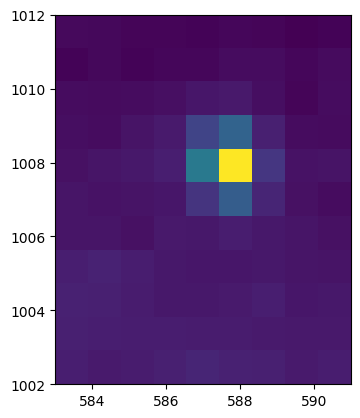

In [61]:
# Plot the mean value for each pixel
plt.imshow(cube[0,:,:].mean(axis=0)[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 

plt.show()


In [62]:
# by default, axis=None, which gives the mean of all data in all dimensions
cube.mean(axis=None)

(490.68353, Uncertainty(0.00184842))

In [63]:
# TODO: can't do cube.uncertainty.mean(). Is this fine? Yes, leave uncertainty math alone
cube.uncertainty.array.mean()

0.96991456

## 3.4 - BitwiseCubes

As mentioned in the introduction, BitwiseCube was developed to handle the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) and [Kepler/K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf#page=18) quality masks. The quality flags are stored in a bitwise operation so that we can easily disentangle all flags attributed to a given time step. When 'adding' bitwise flags, for example when downsampling, we want BitwiseCubes to keep track of all flags that are triggered over the time step. Let's see how this looks in practice below. 

In [65]:
quality_flags = lcf[1].data['QUALITY']
print(quality_flags)
print(np.unique(quality_flags))

[128 128 128 ...   0   0   0]
[    0    32   128   164 16384 16416 16512]


We can see above that a number of quality flags can be found in this TPF. These include
- 0: No quality flag
- 32: Reaction Wheel desaturation Event
- 128: Manual Exclude. The cadence was excluded because of an anomaly
- 164: (128+32+4) Manual Exclude. The cadence was excluded because of an anomaly + Reaction Wheel desaturation Event + Spacecraft is in Coarse Point
- 16384: Bad Calibration Exclude (pipeline >= spoc-4.0.14)
- 16416: (16384 + 32) Bad Calibration Exclude + Reaction Wheel desaturation Event
- 16512: (16384 + 128) Bad Calibration Exclude + Manual Exclude due to an anomaly.

In [66]:
bitwise = lkdata.BitwiseSeries(data=quality_flags,
                       time_indices={'time':time + 2457000},
                          )
bitwise

📗 BitwiseSeries (3450,)

In [67]:
ds = lkdata.DataSeries(data=np.random.random(len(time)),
                       time_indices={'time':time + 2457000},
                          )
ds.downsample(nframes=5, level='time_index')

mid_index  indices                     time        
2.0        [0 1 2 3 4]                 2.459526e+06    3.122328
7.0        [5 6 7 8 9]                 2.459526e+06    2.879047
12.0       [10 11 12 13 14]            2.459526e+06    2.000026
17.0       [15 16 17 18 19]            2.459526e+06    2.331499
22.0       [20 21 22 23 24]            2.459526e+06    2.867625
                                                         ...   
3427.0     [3425 3426 3427 3428 3429]  2.459550e+06    2.286304
3432.0     [3430 3431 3432 3433 3434]  2.459551e+06    2.008093
3437.0     [3435 3436 3437 3438 3439]  2.459551e+06    1.605930
3442.0     [3440 3441 3442 3443 3444]  2.459551e+06    2.220116
3447.0     [3445 3446 3447 3448 3449]  2.459551e+06    2.165188
Length: 690, dtype: float64


📉 DataSeries (690,)

In [68]:
# If we 'sum' the bitwise set, we get a list of all individual flags that are found in the BitwiseSet
bitwise.sum()

BitSet {4, 32, 128, 16384}

In [69]:
# downsampling a BitwiseSeries gives the sum of all individual flags found in each bin. 

bitwise.downsample(level='time',nframes=5)

📗 BitwiseSeries (687,)

# 3 - Putting it all together with DataSet

Now that we understand the different classes in lkdata, let's try to put it all together. For example, a DataSeries can only contain one data array, but what if we want to tie multiple bits of data together? For example, we may want to track the [Simple Aperture Photometry (SAP) as well as the Pre-search Data Conditioning-SAP (PDCSAP)](https://heasarc.gsfc.nasa.gov/docs/tess/LightCurveFile-Object-Tutorial.html) so that if we manipulate the data (by downsampling or slicing) the operation is performed on both DataSets with one command. DataSets allow us to do this. They are also flexible enough to handle any of the different types of data products (DataSeries/Frame/Cube, BoolSeries/Frame/Cube, BitwiseSeries/Frame/Cube). Let's use our K2-18 data from Section 3 as an example. 

When defining a dataset, you need to specify the type of data products (data, boolean, or bitwise) you are including. If you do not specify, the DataSet will assume you will provide them in order (Data products, then Boolean products, then Bitwise products, and finally additional properties). 


In [70]:
# TODO: DataSet docstring is not clear with how DataSet init works. 
# TODO: how do aperturew get handled? 


lkdata.DataSet({'tpf':cube, 'quality':bitwise})



Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True, 'quality': 📗 BitwiseSeries (3450,)}
Bool Products:
{}
Bitwise Products:
{}
Properties:
[]

In [71]:
# if you don't specify the type of products, DataSet will assume these are defined in order. 
# Note that our bitwise products is wrongly classified as a Bool Product in this case. 
lkdata.DataSet({'tpf':cube}, {'quality':bitwise})


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality': 📗 BitwiseSeries (3450,)}
Bitwise Products:
{}
Properties:
[]

In [72]:
# To be safe, it is always advised to specify the data type for each input. 
dset = lkdata.DataSet(data_products={'tpf':cube}, 
               bool_products={'quality_flag':bitwise.values >0},
               bitwise_products={'quality':bitwise},
               target='K2-18')
dset


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (3450,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
['target']

In [73]:
# TODO: I expect there to be a describe_cube function like there is for the other products
dset.describe_set()

AttributeError: 'DataSet' object has no attribute 'describe_set'

In [74]:
# You can easily access the metadata by key
dset.target

'K2-18'

Now when performing operations such as slicing or downsampling, the operation will apply to every item contained in the DataSet. For example, if we want to bin by time, the downsample will apply to every product that has a time dimension. Spatial downsampling, on the other hand, will only apply to products that contain 3-D information (image data). Slicing is similar, where if you slices made in the time dimension happen for all data products, but row/column slices only happen on 3D data. 

In [98]:
# Note all data products have been downsampled in the time dimension
dset.downsample(nframes=2)


Data Products:
{'tpf': 📘 DataCube (1722, 11, 9), Uncertainty: False}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (1722,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (1722,)}
Properties:
['target']

In [99]:
dset.spatial_downsample(factor=2)



Data Products:
{'tpf': 📘 DataCube (3450, 5, 4), Uncertainty: False}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (3450,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
['target']

In [100]:
# Slice by keeping every 5th time step
dset[::5, :,:]


Data Products:
{'tpf': 📘 DataCube (690, 11, 9), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (690,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (690,)}
Properties:
['target', 'columns']

In [101]:
# Keep the first 100 time steps, and the first two row/columns for any DataCube products.
dset[:100, :2,:2]


Data Products:
{'tpf': 📘 DataCube (100, 2, 2), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (100,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (100,)}
Properties:
['target', 'columns']

You can access a specific data product by name. This will return the underlying DataSeries, SeriesCollection, or DataCube. 

In [102]:
dset[:100, :2,:2]['tpf']

📘 DataCube (100, 2, 2), Uncertainty: True

# Conclusion

lkdata provides a backbone to quickly handle timeseries-like data. As lkdata is built on pandas DataFrames, transformations such as slicing and binning are easily (and quickly) accomplished. 

This tutorial covered how we can represent real data from TESS using lkdata.  These examples serve as building blocks to construct larger and more powerful DataSets. 

The latest release of lighkurve builds upon these basic structures. While lightkurve handles setting up the DataSets for TESS/Kepler/K2 data products for users, this tutorial provides a 'look under the hood' to demonstrate the basic structure and functionality that can be used. 